# Baseline models

Goal: Make baseline predictions by averaging rain, crop, and surplus data over the entire basin for a single site.
Currently using site WQS0039 but can be updated to any uid.

To do:
- Normalize crops over basin area 
- Normalize rain over basin area 
- Compare nitrate to average over day instead of max for linear regression (DONE)
- Create surplus x rain data per day by using the surplus data in 2017 at each grid (needs grid_id added to rain data) (DONE)
- Explore different features more, determine if any are good. (Surplus x rain seems to be best right now)
- Additional EDA beyond pair plot, test with other basins
- Create baseline model for multiple sites and test on a separate site

In [14]:
import sys
sys.path.insert(0, "../") # replace with path/to/project/root
from data import get_data, get_site_ids

import pandas as pd
import numpy as np


In [15]:
uid = "WQS0083"

data = get_data(site_uid=uid)

daily_avg_precip = ( # calculate average percipitation over entire basin for each date
    data.rain.groupby("date", as_index=False)["precip_in_1d"]
      .mean()
)

# Take sum of crops over the entire basin (figure out how to normalized)
crops = data.crops.groupby("year", as_index=False).sum() 

# Calculate mean surplus nitrogen over basin in 2017. This does not work as a feature because it is constant.
nitrogen_2017 = data.surplus[data.surplus['year'] == 2017]
SURPLUS_N_2017 = nitrogen_2017['surplus_kgha'].mean()



In [16]:
from data.water import aggregate_by_interval

# Aggregate water levels to each calendar day. I used max so we coult track violations,
# but might need to be average for a continuous model. This could explain why linreg is so bad.
water_max = aggregate_by_interval(site_uid=uid, value_col="nitrate_con", interval="1D", agg_func="max").to_frame()
water_max["date"] = water_max.index.date
water_max = water_max.reset_index(drop=True).rename(columns={'nitrate_con':'nitrate_max'})

water = aggregate_by_interval(site_uid=uid, value_col="nitrate_con", interval="1D", agg_func="mean").to_frame()
water["date"] = water.index.date
water = water.reset_index(drop=True)
water = pd.merge(water, water_max, on="date")

water

# Create true/false column if there was a single violation in a calendar day
water["violation"] = (water.nitrate_max > 10).astype(int)
print("Violation counts:\n", water["violation"].value_counts()) # Check counts of violations
water



Violation counts:
 violation
0    2756
1     125
Name: count, dtype: int64


,nitrate_con,date,nitrate_max,violation
0,4.350333,2018-07-20,4.48,0
1,4.456354,2018-07-21,5.33,0
2,5.934271,2018-07-22,6.27,0
3,6.221250,2018-07-23,6.29,0
4,5.868437,2018-07-24,6.13,0
...,...,...,...,...
2876,3.345660,2026-06-04,6.57,0
2877,6.796215,2026-06-05,6.91,0
2878,6.805000,2026-06-06,8.15,0
2879,9.180634,2026-06-07,9.74,0


In [17]:
# Make datetime stuff compatible
water["date"] = pd.to_datetime(water["date"])
daily_avg_precip["date"] = pd.to_datetime(daily_avg_precip["date"])


# Merge water data with daily average percipitation
df = water[["date", "violation", "nitrate_con"]].merge(
    daily_avg_precip,
    on="date",
    how="left"
)
df


,date,violation,nitrate_con,precip_in_1d
0,2018-07-20,0,4.350333,0.019498
1,2018-07-21,0,4.456354,0.000000
2,2018-07-22,0,5.934271,0.000000
3,2018-07-23,0,6.221250,0.005284
4,2018-07-24,0,5.868437,0.000000
...,...,...,...,...
2876,2026-06-04,0,3.345660,0.439699
2877,2026-06-05,0,6.796215,0.000268
2878,2026-06-06,0,6.805000,0.002642
2879,2026-06-07,0,9.180634,0.196522


In [18]:
# Add in gridded rain_x_surplus data
rain = pd.merge(data.rain, data.grid[['node_id', 'cell_area', 'geometry']], how='left', on='node_id')
rain = pd.merge(rain, nitrogen_2017, on='node_id')
rain['rain_x_surplus'] = rain.precip_in_1d * rain.surplus_kgha

daily_rain_x_surplus = ( # calculate average rain_x_surplus over entire basin for each date
    rain.groupby("date", as_index=False)["rain_x_surplus"]
      .mean()
)

df = pd.merge(df, daily_rain_x_surplus, on = 'date')

# Add in 7,14, and 30 day rolling averages
df["rain_x_surplus_7d"]  = df["rain_x_surplus"].rolling(7,  min_periods=1).sum()
df["rain_x_surplus_14d"] = df["rain_x_surplus"].rolling(14, min_periods=1).sum()
df["rain_x_surplus_30d"] = df["rain_x_surplus"].rolling(30, min_periods=1).sum()

In [19]:
# Add in 7,14, and 30 day rolling averages
df["rain_7d"]  = df["precip_in_1d"].rolling(7,  min_periods=1).sum()
df["rain_14d"] = df["precip_in_1d"].rolling(14, min_periods=1).sum()
df["rain_30d"] = df["precip_in_1d"].rolling(30, min_periods=1).sum()

# Crop data is yearly -> broadcast onto every day in that crop year.
df["year"] = df["date"].dt.year
df = df.merge(crops.drop(columns='node_id'), on="year", how="left")      
 
# Surplus N is a single static estimate -> constant column. Will only matter for multiple sites.
df["surplus_n_2017"] = SURPLUS_N_2017
 
# Autoregressive features: nitrate is autocorrelated, recent readings matter
df["nitrate_lag1"] = df["nitrate_con"]            # today's reading
df["nitrate_lag2"] = df["nitrate_con"].shift(1)
df["nitrate_lag3"] = df["nitrate_con"].shift(2)

df


,date,violation,nitrate_con,precip_in_1d,rain_x_surplus,rain_x_surplus_7d,rain_x_surplus_14d,rain_x_surplus_30d,rain_7d,rain_14d,...,Fallow,Hay_Pasture,Nonag,Other,Small_Grains,Soybeans,surplus_n_2017,nitrate_lag1,nitrate_lag2,nitrate_lag3
0,2018-07-20,0,4.350333,0.019498,1.373428,1.373428,1.373428,1.373428,0.019498,0.019498,...,3495.0,570324.0,982209.0,1593.0,8695.0,1962411.0,72.991428,4.350333,NaN,NaN
1,2018-07-21,0,4.456354,0.000000,0.000000,1.373428,1.373428,1.373428,0.019498,0.019498,...,3495.0,570324.0,982209.0,1593.0,8695.0,1962411.0,72.991428,4.456354,4.350333,NaN
2,2018-07-22,0,5.934271,0.000000,0.000000,1.373428,1.373428,1.373428,0.019498,0.019498,...,3495.0,570324.0,982209.0,1593.0,8695.0,1962411.0,72.991428,5.934271,4.456354,4.350333
3,2018-07-23,0,6.221250,0.005284,0.449936,1.823364,1.823364,1.823364,0.024783,0.024783,...,3495.0,570324.0,982209.0,1593.0,8695.0,1962411.0,72.991428,6.221250,5.934271,4.456354
4,2018-07-24,0,5.868437,0.000000,0.000000,1.823364,1.823364,1.823364,0.024783,0.024783,...,3495.0,570324.0,982209.0,1593.0,8695.0,1962411.0,72.991428,5.868437,6.221250,5.934271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2867,2026-06-04,0,3.345660,0.439699,35.751183,53.573018,116.217388,225.752944,0.668294,1.565184,...,NaN,NaN,NaN,NaN,NaN,NaN,72.991428,3.345660,3.208194,4.867639
2868,2026-06-05,0,6.796215,0.000268,0.020416,53.593434,105.683975,225.773360,0.668562,1.408161,...,NaN,NaN,NaN,NaN,NaN,NaN,72.991428,6.796215,3.345660,3.208194
2869,2026-06-06,0,6.805000,0.002642,0.236327,53.605296,99.068387,226.009687,0.668595,1.312341,...,NaN,NaN,NaN,NaN,NaN,NaN,72.991428,6.805000,6.796215,3.345660
2870,2026-06-07,0,9.180634,0.196522,14.497302,50.507447,112.537754,240.506990,0.639164,1.493177,...,NaN,NaN,NaN,NaN,NaN,NaN,72.991428,9.180634,6.805000,6.796215


In [20]:
# Add in columns that allow for dummy models (yesterday's value = today's value)
df["nitrate_tomorrow"]   = df["nitrate_con"].shift(-1)
df["violation_tomorrow"] = (df["violation"].shift(-1))
 
# Remove null variables
df = df.dropna(subset=["nitrate_tomorrow", "nitrate_lag3", "nitrate_con"]).reset_index(drop=True)
df  # Look at all features in dataframe

,date,violation,nitrate_con,precip_in_1d,rain_x_surplus,rain_x_surplus_7d,rain_x_surplus_14d,rain_x_surplus_30d,rain_7d,rain_14d,...,Nonag,Other,Small_Grains,Soybeans,surplus_n_2017,nitrate_lag1,nitrate_lag2,nitrate_lag3,nitrate_tomorrow,violation_tomorrow
0,2018-07-22,0,5.934271,0.000000,0.000000,1.373428,1.373428,1.373428,0.019498,0.019498,...,982209.0,1593.0,8695.0,1962411.0,72.991428,5.934271,4.456354,4.350333,6.221250,0.0
1,2018-07-23,0,6.221250,0.005284,0.449936,1.823364,1.823364,1.823364,0.024783,0.024783,...,982209.0,1593.0,8695.0,1962411.0,72.991428,6.221250,5.934271,4.456354,5.868437,0.0
2,2018-07-24,0,5.868437,0.000000,0.000000,1.823364,1.823364,1.823364,0.024783,0.024783,...,982209.0,1593.0,8695.0,1962411.0,72.991428,5.868437,6.221250,5.934271,5.308646,0.0
3,2018-07-25,0,5.308646,0.465485,33.908493,35.731857,35.731857,35.731857,0.490268,0.490268,...,982209.0,1593.0,8695.0,1962411.0,72.991428,5.308646,5.868437,6.221250,4.665625,0.0
4,2018-07-26,0,4.665625,0.000000,0.000000,35.731857,35.731857,35.731857,0.490268,0.490268,...,982209.0,1593.0,8695.0,1962411.0,72.991428,4.665625,5.308646,5.868437,4.085000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1668,2026-06-03,0,3.208194,0.000000,0.000000,17.821834,80.510816,190.001761,0.228595,1.126054,...,NaN,NaN,NaN,NaN,72.991428,3.208194,4.867639,5.331771,3.345660,0.0
1669,2026-06-04,0,3.345660,0.439699,35.751183,53.573018,116.217388,225.752944,0.668294,1.565184,...,NaN,NaN,NaN,NaN,72.991428,3.345660,3.208194,4.867639,6.796215,0.0
1670,2026-06-05,0,6.796215,0.000268,0.020416,53.593434,105.683975,225.773360,0.668562,1.408161,...,NaN,NaN,NaN,NaN,72.991428,6.796215,3.345660,3.208194,6.805000,0.0
1671,2026-06-06,0,6.805000,0.002642,0.236327,53.605296,99.068387,226.009687,0.668595,1.312341,...,NaN,NaN,NaN,NaN,72.991428,6.805000,6.796215,3.345660,9.180634,0.0


In [21]:
# Check seasonality of violations. Indicate that this time series should possibly be handled as periodic/seasonal.

df["month"] = df["date"].dt.month
monthly = df.groupby("month")["violation_tomorrow"].agg(["sum", "count"])
monthly["rate"] = monthly["sum"] / monthly["count"]
print("Violations by month:\n", monthly, "\n")
 
top_month_share = monthly["sum"].max() / monthly["sum"].sum()
print(f"Largest single month holds {top_month_share:.0%} of all violations.")
if top_month_share > 0.35:
    print("WARNING: violations are heavily seasonal. A plain chronological "
          "split may starve some folds of positives -- consider checking "
          "fold-level violation counts below, or stratifying by season "
          "instead of pure date order.\n")
else:
    print("Violations are reasonably spread across the year.\n")


Violations by month:
         sum  count      rate
month                       
3       4.0     48  0.083333
4      19.0    133  0.142857
5      43.0    232  0.185345
6      48.0    211  0.227488
7       8.0    224  0.035714
8       0.0    241  0.000000
9       0.0    217  0.000000
10      0.0    197  0.000000
11      0.0    144  0.000000
12      0.0     26  0.000000 

Largest single month holds 39% of all violations.



## Edit included features here!

In [22]:
cutoff = df["date"].quantile(0.8)          # last ~20% of days held out
train = df[df["date"] <= cutoff]
hold_out  = df[df["date"] >  cutoff]
 
crop_cols = [c for c in crops.columns if c not in ["year", "node_id"]]

# PLAY AROUND HERE WITH DIFFERENT FEATURES TO DETERMINE WHICH ONES YOU WANT TO INCLUDE.
# ALL POSSIBLE FEATURES ARE INCLUDED IN THE commented feature_cols LIST.

# feature_cols = (["precip_in_1d", "rain_7d", "rain_14d", "rain_30d", "surplus_x_rain30",
#                   "nitrate_lag1", "nitrate_lag2", "nitrate_lag3", "rain_x_surplus",
#                    "rain_x_surplus_7d", "rain_x_surplus_14d", "rain_x_surplus_30d"]
#                  + crop_cols)
feature_cols = (["nitrate_lag1", "rain_x_surplus_7d"])
 
X = train[feature_cols].fillna(0).values    # train on all features for training data. Fix null values
y_class = train["violation_tomorrow"].values
y_reg   = train["nitrate_tomorrow"].values
today_value = train["nitrate_con"].values   # needed for the random-walk baseline

 

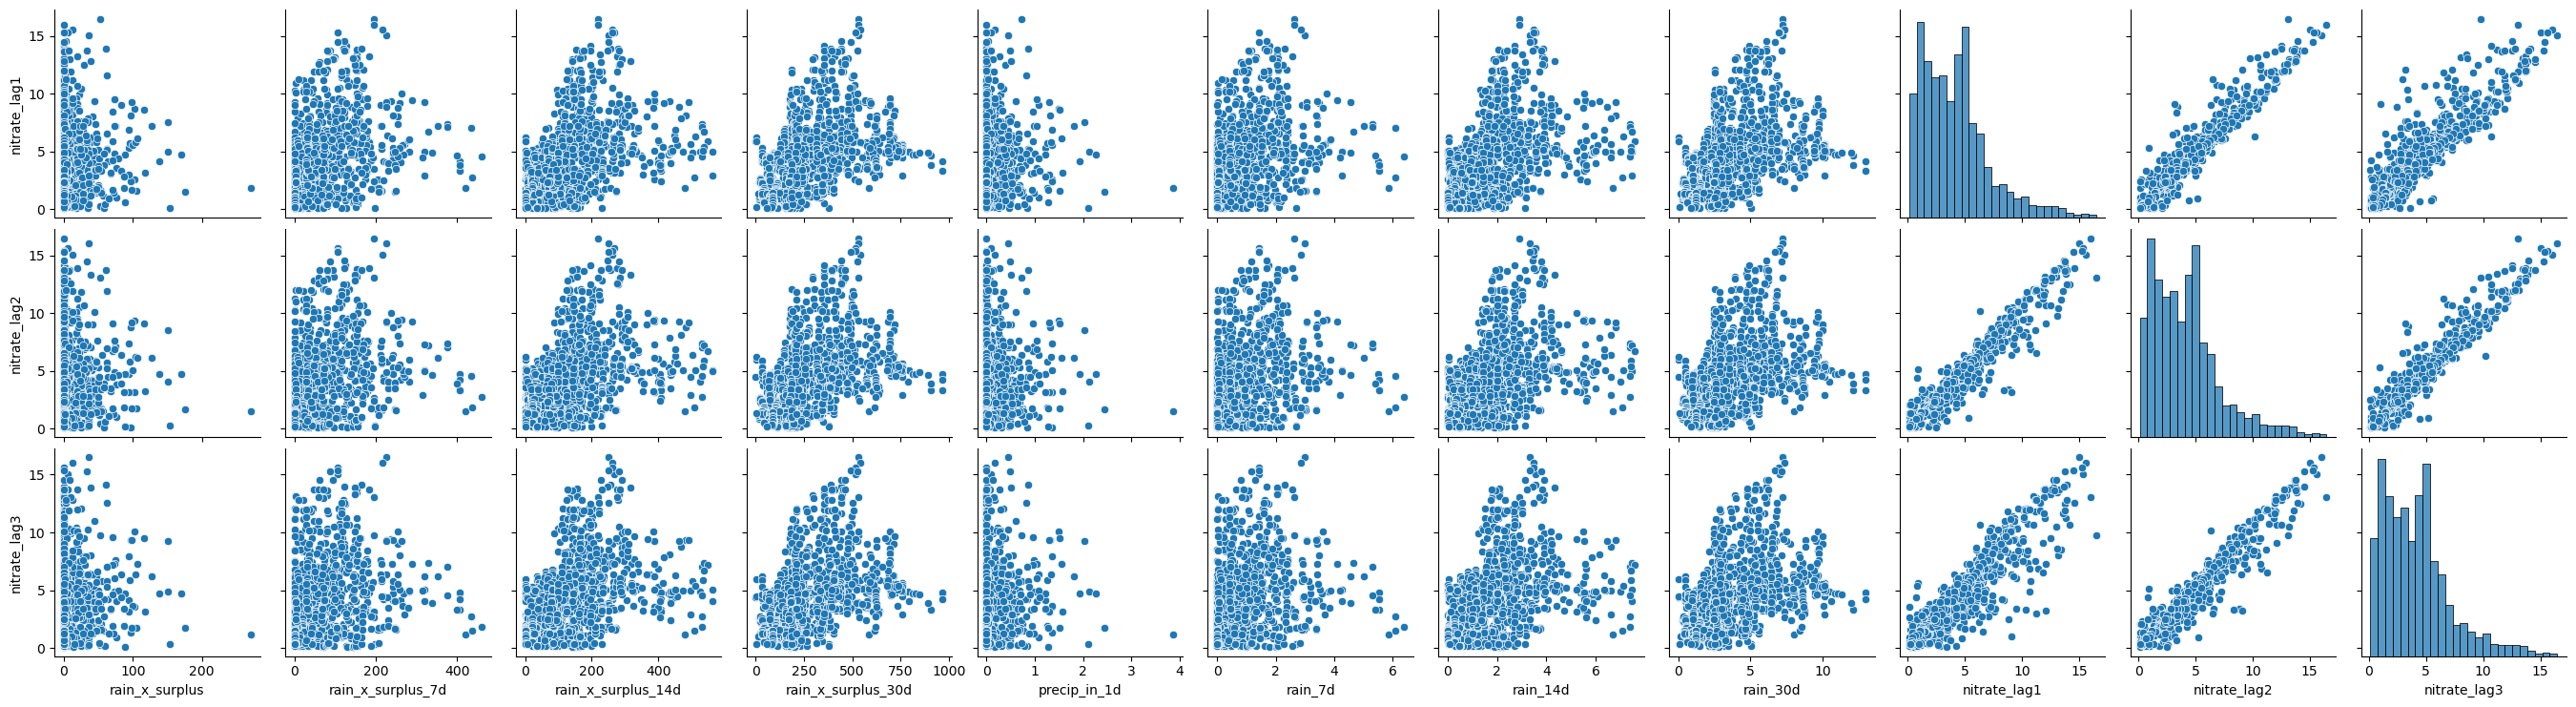

In [23]:
import seaborn as sns

sns.pairplot(train[["rain_x_surplus", "rain_x_surplus_7d", "rain_x_surplus_14d", "rain_x_surplus_30d", "precip_in_1d", "rain_7d", "rain_14d", "rain_30d", "nitrate_lag1","nitrate_lag2","nitrate_lag3"]], y_vars=["nitrate_lag1","nitrate_lag2","nitrate_lag3"])

The remainder is testing different baseline models on the formatted data.

In [24]:
from scipy.stats import norm
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import average_precision_score, mean_absolute_error, mean_squared_error
 

# ------------------------------------------------------------------
# 6. TIME SERIES CROSS-VALIDATION
# TimeSeriesSplit always trains on the past and tests on a later, contiguous
# block -- never shuffles, never tests on data that precedes training data.
# ------------------------------------------------------------------
N_SPLITS = 3
tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=100)
 
results = {k: [] for k in [
    "dummy_most_frequent_AP", "dummy_stratified_AP",
    "gaussian_rw_classifier_AP", "logreg_AP",
    "persistence_regression_MAE", "persistence_regression_RMSE",
    "linreg_MAE", "linreg_RMSE",
]}
 
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X[train_idx], X[test_idx]
    yc_train, yc_test = y_class[train_idx], y_class[test_idx]
    yr_train, yr_test = y_reg[train_idx], y_reg[test_idx]
    today_train, today_test = today_value[train_idx], today_value[test_idx]
 
    print(f"Fold {fold}: train={len(train_idx)}  test={len(test_idx)}  "
          f"test_violations={yc_test.sum()}")
    if yc_test.sum() == 0:
        print("  WARNING: this fold has zero violations -- AP undefined/misleading for it.")
 
    # --- Dummy classifiers (the honest floor) ---
    for strategy, key in [("most_frequent", "dummy_most_frequent_AP"),
                           ("stratified", "dummy_stratified_AP")]:
        dummy = DummyClassifier(strategy=strategy, random_state=0)
        dummy.fit(X_train, yc_train)
        ap = average_precision_score(yc_test, dummy.predict_proba(X_test)[:, 1])
        results[key].append(ap)
 
    # --- Gaussian random walk ---
    # sigma estimated from TRAINING differences only -- no future leakage
    train_diffs = np.diff(today_train)
    sigma = max(np.std(train_diffs), 1e-6) if len(train_diffs) > 1 else 1.0

    # classification view: P(tomorrow > 10 | today) under N(today, sigma^2)
    rw_proba = 1 - norm.cdf((10 - today_test) / sigma)
    results["gaussian_rw_classifier_AP"].append(average_precision_score(yc_test, rw_proba))
 
    # regression view: point forecast = today's value (persistence)
    persistence_pred = today_test
    results["persistence_regression_MAE"].append(mean_absolute_error(yr_test, persistence_pred))
    results["persistence_regression_RMSE"].append(np.sqrt(mean_squared_error(yr_test, persistence_pred)))
 
    # --- Logistic regression (feature-based classification) ---
    logreg = make_pipeline(StandardScaler(),
                            LogisticRegression(class_weight="balanced", max_iter=1000))
    logreg.fit(X_train, yc_train)
    ap_lr = average_precision_score(yc_test, logreg.predict_proba(X_test)[:, 1])
    results["logreg_AP"].append(ap_lr)
 
    # --- Linear regression (feature-based regression) ---
    linreg = make_pipeline(StandardScaler(), LinearRegression())
    linreg.fit(X_train, yr_train)
    lr_pred = linreg.predict(X_test)
    results["linreg_MAE"].append(mean_absolute_error(yr_test, lr_pred))
    results["linreg_RMSE"].append(np.sqrt(mean_squared_error(yr_test, lr_pred)))
 


Fold 0: train=1038  test=100  test_violations=3.0
Fold 1: train=1138  test=100  test_violations=22.0
Fold 2: train=1238  test=100  test_violations=34.0


In [25]:
# ------------------------------------------------------------------
# 7. SUMMARY ACROSS FOLDS
# ------------------------------------------------------------------
print("\n=== Cross-validated results (mean +/- std across folds) ===")
print("\n-- Classification (Average Precision / PR-AUC, higher is better) --")
for key in ["dummy_most_frequent_AP", "dummy_stratified_AP",
            "gaussian_rw_classifier_AP", "logreg_AP"]:
    vals = np.array(results[key])
    print(f"{key:30s}: {vals.mean():.4f} +/- {vals.std():.4f}")
 
print("\n-- Regression (MAE / RMSE in mg/L, lower is better) --")
for key in ["persistence_regression_MAE", "persistence_regression_RMSE",
            "linreg_MAE", "linreg_RMSE"]:
    vals = np.array(results[key])
    print(f"{key:30s}: {vals.mean():.4f} +/- {vals.std():.4f}")
 
# ------------------------------------------------------------------
# HOW TO READ THIS:
# - The Gaussian random walk should beat the dummy classifiers by a wide
#   margin (it has the nontrivial advantage of knowing today's value).
#   If logreg can't beat the random walk, your engineered features (rain,
#   crops, surplus N) aren't adding information beyond "what happened
#   yesterday" -- which is a meaningful, honest finding on its own.
# - Same logic for regression: linreg should beat plain persistence, or
#   your features aren't earning their keep yet.
# ------------------------------------------------------------------
 



=== Cross-validated results (mean +/- std across folds) ===

-- Classification (Average Precision / PR-AUC, higher is better) --
dummy_most_frequent_AP        : 0.1967 +/- 0.1276
dummy_stratified_AP           : 0.1983 +/- 0.1290
gaussian_rw_classifier_AP     : 0.9593 +/- 0.0290
logreg_AP                     : 0.9633 +/- 0.0341

-- Regression (MAE / RMSE in mg/L, lower is better) --
persistence_regression_MAE    : 0.5480 +/- 0.1203
persistence_regression_RMSE   : 0.9043 +/- 0.2463
linreg_MAE                    : 0.4898 +/- 0.1175
linreg_RMSE                   : 0.8504 +/- 0.2508


In [26]:
# Ignore this cell, want to try and model on my own, but obviously haven't gotten very far.

## Import TimeSeriesSplit
from sklearn.model_selection import TimeSeriesSplit

kfold = TimeSeriesSplit(n_splits = 5)

# for train_index, test_index in kfold.split(train):
#     print("TRAIN INDEX SIZE:", train_index)
#     print("TEST INDEX SIZE:", test_index)
#     print()